In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("pod_gpu_duty_cycle_anon.csv")


# Convert columns to numbers
df["timestamp_anon"] = pd.to_numeric(df["timestamp_anon"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Remove rows with missing values
df = df.dropna(subset=["timestamp_anon", "value", "container_ip"])

# Sort by time
df = df.sort_values("timestamp_anon")

#look at all timestamp_anon column, find the minimum and store in start_time
start_time = df["timestamp_anon"].min()

#subtract first timestamp from every row to get 
df["elapsed_seconds"] = df["timestamp_anon"] - start_time

# Convert seconds to hours
df["elapsed_hours"] = df["elapsed_seconds"] / 3600

#MAKE 1 minute bins
BIN_SIZE = 60  

df["time_bin"] = (df["elapsed_seconds"] // BIN_SIZE) * BIN_SIZE

# convert 1 minute bins into hours
df["time_bin_hours"] = df["time_bin"] / 3600

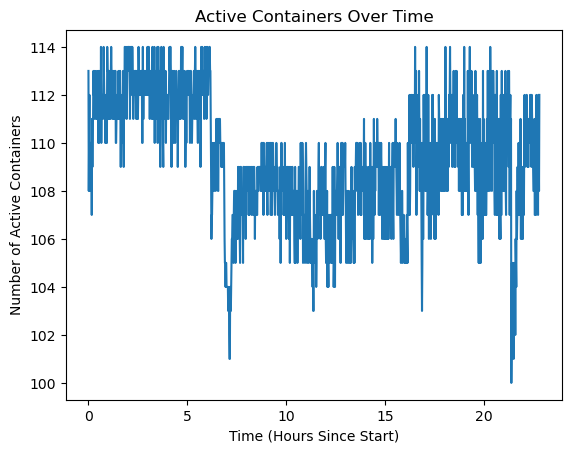

In [3]:
#For each time bin (each minute), count how many different container_ip values appeared.
container_count = df.groupby("time_bin_hours")["container_ip"].nunique()

# Convert to a normal DataFrame
container_count = container_count.reset_index()

# Plot
plt.figure()
plt.plot(container_count["time_bin_hours"],
         container_count["container_ip"])

plt.xlabel("Time (Hours Since Start)")
plt.ylabel("Number of Active Containers")
plt.title("Active Containers Over Time")
plt.show()

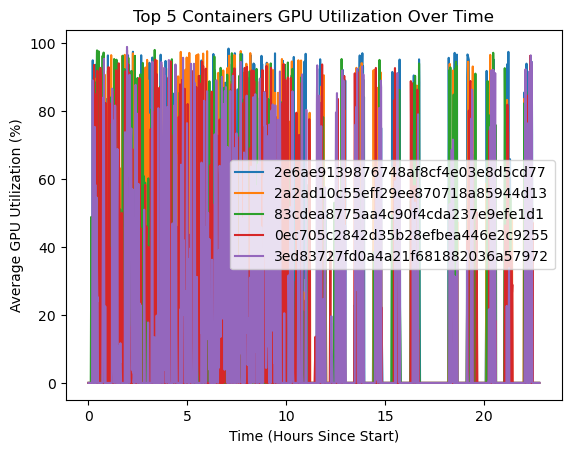

In [4]:
avg_usage = df.groupby("container_ip")["value"].mean()

# Sort from highest to lowest
avg_usage = avg_usage.sort_values(ascending=False)

# Get the top 5 container IDs since plotting all 143 unique containers is too crowded on a graph
top_containers = avg_usage.head(5).index

#Compute average usage per time bin per container
grouped = df.groupby(["time_bin_hours", "container_ip"])["value"].mean()
grouped = grouped.reset_index()

#keep only the top 5 containers 
filtered = grouped[grouped["container_ip"].isin(top_containers)]

plt.figure()

for container in top_containers:
    container_data = filtered[filtered["container_ip"] == container]
    plt.plot(container_data["time_bin_hours"],
             container_data["value"],
             label=container)

plt.xlabel("Time (Hours Since Start)")
plt.ylabel("Average GPU Utilization (%)")
plt.title("Top 5 Containers GPU Utilization Over Time")
plt.legend()
plt.show()

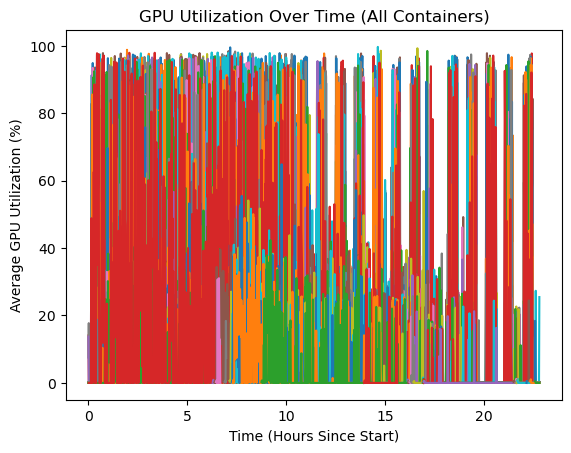

In [5]:
#Compute average GPU usage per time bin per container
grouped = df.groupby(["time_bin_hours", "container_ip"])["value"].mean()
grouped = grouped.reset_index()

plt.figure()

# Loop through every container and plot time_bin_hours vs value
for container in grouped["container_ip"].unique():
    container_data = grouped[grouped["container_ip"] == container]
    plt.plot(container_data["time_bin_hours"],
             container_data["value"])

plt.xlabel("Time (Hours Since Start)")
plt.ylabel("Average GPU Utilization (%)")
plt.title("GPU Utilization Over Time (All Containers)")
plt.show()